In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
df = pd.read_csv("Data/heart.csv")

In [3]:
import sklearn
print(sklearn.__version__)

1.9.0


In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1025, 14)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [11]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()


In [12]:
print(df.shape)

(302, 14)


Data is Cleaned Now

In [13]:
X = df.drop("target", axis=1)
y = df["target"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Featued Engineering

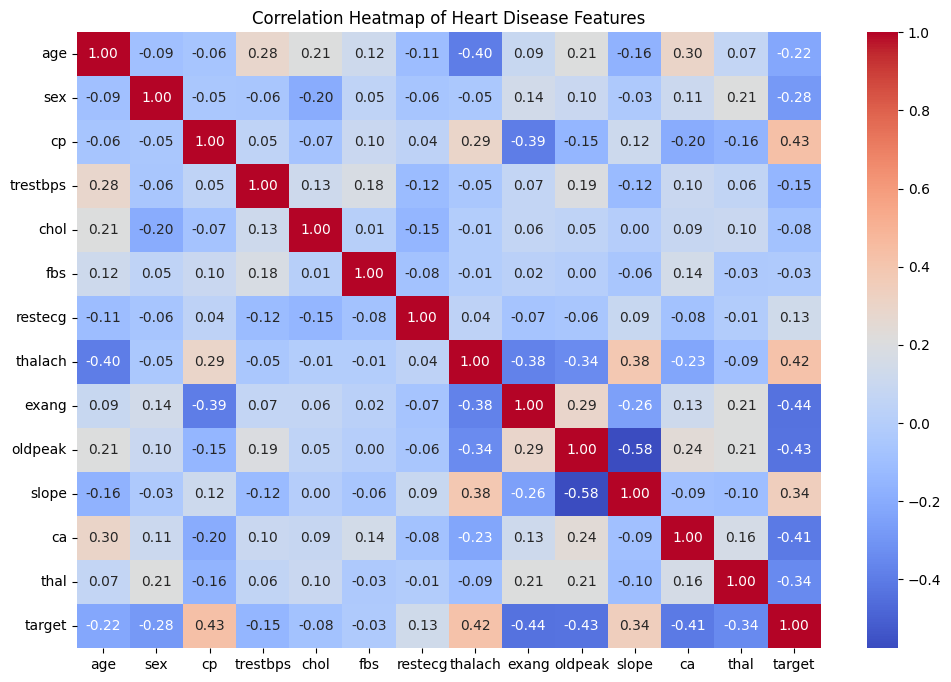

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Heart Disease Features")
plt.show()

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest for feature importance
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X, y)

# Get importance scores
importance = rf_model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

     Feature  Importance
7    thalach    0.134202
2         cp    0.128033
9    oldpeak    0.115018
11        ca    0.108043
12      thal    0.099852
0        age    0.090054
4       chol    0.074063
3   trestbps    0.071019
8      exang    0.060830
10     slope    0.051134
1        sex    0.038703
6    restecg    0.021519
5        fbs    0.007529


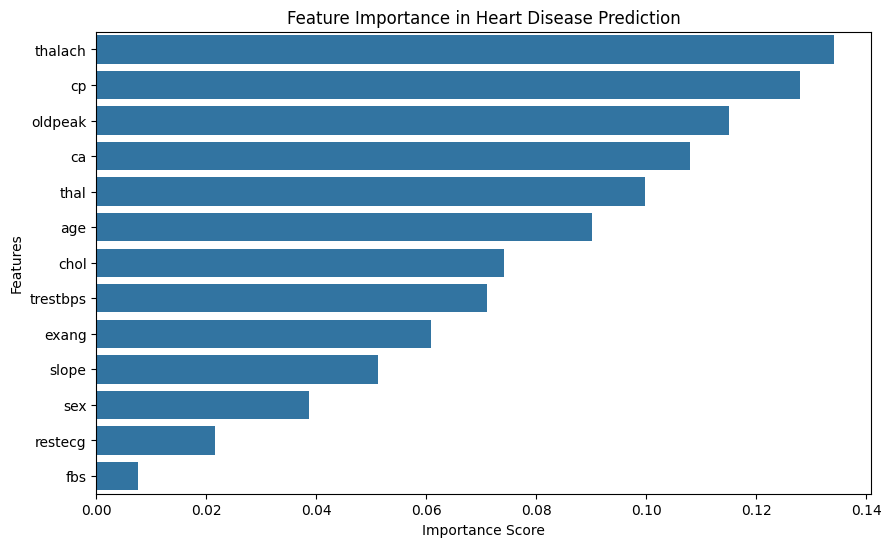

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance in Heart Disease Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

Train Different Machine Learning Models

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [20]:
# Create model
lr_model = LogisticRegression(random_state=42)

# Train model
lr_model.fit(X_train_scaled, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test_scaled)

In [21]:
# Create model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Make predictions
dt_pred = dt_model.predict(X_test)

In [22]:
# Create model
rf_model = RandomForestClassifier(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

Model Evaluation & Comparison

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [24]:
# Create an empty list to store results
results = []

# Store predictions
models = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

# Calculate metrics for each model
for name, prediction in models.items():
    results.append([
        name,
        accuracy_score(y_test, prediction),
        precision_score(y_test, prediction),
        recall_score(y_test, prediction),
        f1_score(y_test, prediction)
    ])

# Create comparison table
comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

# Display results
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.770492,0.702703,0.896552,0.787879
1,Decision Tree,0.737705,0.740741,0.689655,0.714286
2,Random Forest,0.836066,0.787879,0.896552,0.838710


In [25]:
comparison = comparison.round(3)
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.836,0.788,0.897,0.839
0,Logistic Regression,0.770,0.703,0.897,0.788
1,Decision Tree,0.738,0.741,0.690,0.714


Best Model Analysis

In [26]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.836,0.788,0.897,0.839
0,Logistic Regression,0.770,0.703,0.897,0.788
1,Decision Tree,0.738,0.741,0.690,0.714


In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [28]:
cm = confusion_matrix(y_test, rf_pred)

print(cm)

[[25  7]
 [ 3 26]]


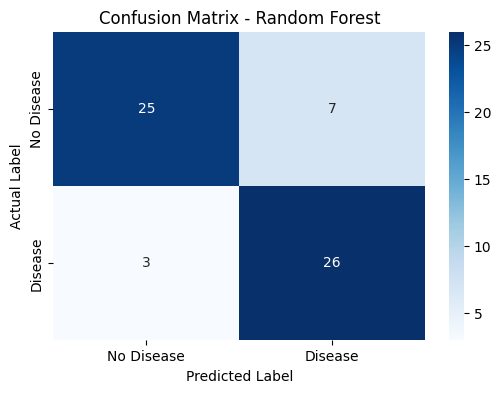

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")

plt.show()